# LUCA NICOLOSI - 1000047978

# PART 1 - Data Warehouse Modeling: Star Schema

## 1.1 Define the Business Process and the Fact Grain

---

### 💼 1. The Business Process

> **Definition:** The business process under analysis is the formal tracking, monitoring, and auditing of financial asset portfolio transactions.

The core objective of this dimensional model is to evaluate operational trade volumes, transaction directions, and market performance metrics across distinct economic sectors, industrial niches, and macro-geopolitical regions.

---

### 🎯 2. The Fact Grain

> **Definition:** The grain specifies the exact level of atomic detail represented by a single row within the fact table, establishing the foundation for all downstream analytical roll-ups and aggregations.

In strict compliance with the assignment requirements, the grain of `fact_transactions` is defined at the lowest, non-aggregated operational level (**Transaction-level grain**):

* **Atomic Mapping:** One single row in the central `fact_transactions` table represents exactly **one individual financial trade event**.
* **Data Source Lineage:** Every row corresponds to a single line item extracted directly from the raw operational account statement log file (`account-statement-1-1-2024-12-31-2024.csv`).

---

## 1.2 Identify Fact and Dimensions

In order to map my source attributes into a high-performance dimensional star schema model, I isolate numeric metrics into a single central fact table and descriptive contexts into dimension tables. This architecture guarantees fast query response times and prevents unnecessary data duplication across the database.

---

### 1. The Fact Table: `fact_transactions`

* **Description:** Represents the core quantitative events of my business process. It stores the numeric measures of the financial transactions alongside the foreign keys pointing to the surrounding dimensions.
* **Source File:** `account-statement-1-1-2024-12-31-2024.csv`

| Field Name | Logical Role | Target Relation / Context | Data Type |
| :--- | :--- | :--- | :--- |
| **time_id** | Foreign Key (FK) | `dim_time.time_id` | INTEGER |
| **symbol_id** | Foreign Key (FK) | `dim_symbol.symbol_id` | INTEGER |
| **geography_id** | Foreign Key (FK) | `dim_geography.geography_id` | INTEGER |
| **trans_type_id** | Foreign Key (FK) | `dim_transaction_type.trans_type_id` | INTEGER |
| **quantity** | Numeric Measure | Central Fact Metric (Volume Traded) | DECIMAL |

---

### 2. The Dimension Tables

The following dimension tables provide descriptive context to the facts, separating organizational attributes logically:

#### Dim_Time
* **Description:** Provides full chronological properties for each transaction.

| Field Name | Logical Role | Data Type | Description |
| :--- | :--- | :--- | :--- |
| **time_id** | Primary Key (PK) | INTEGER | Generated unique identifier |
| **date** | Natural Key | DATE | Business entry date (`YYYY-MM-DD`) |
| **day_of_week** | Chronological Attribute | VARCHAR(10) | Day name (e.g., Monday) |
| **month** | Chronological Attribute | INTEGER | Calendar month (1 to 12) |
| **quarter** | Chronological Attribute | INTEGER | Fiscal quarter (1 to 4) |
| **year** | Chronological Attribute | INTEGER | Calendar year (e.g., 2024) |

#### Dim_Geography
* **Description:** Houses geographical metadata for the countries linked to the listed stock companies.

| Field Name | Logical Role | Data Type | Description |
| :--- | :--- | :--- | :--- |
| **geography_id** | Primary Key (PK) | INTEGER | Generated unique identifier |
| **country** | Natural Key | VARCHAR(100) | Standardized country name |
| **region** | Geopolitical Attribute | VARCHAR(50) | Macro-continental region |
| **sub_region** | Geopolitical Attribute | VARCHAR(50) | Geopolitical sub-zone |

#### Dim_Symbol
* **Description:** Contains company profiles and corporate sector/industry classifications for each traded equity.

| Field Name | Logical Role | Data Type | Description |
| :--- | :--- | :--- | :--- |
| **symbol_id** | Primary Key (PK) | INTEGER | Generated unique identifier |
| **symbol_code** | Natural Key | VARCHAR(10) | Stock exchange ticker string |
| **company_name** | Corporate Attribute | VARCHAR(255) | Official legal name of the issuer |
| **sector** | Market Sector Hierarchy | VARCHAR(100) | Macroeconomic sector |
| **industry** | Industrial Niche Attribute | VARCHAR(100) | Specific industrial niche |

#### Dim_Transaction_Type
* **Description:** A dedicated, low-cardinality dimension to cleanly capture whether a transaction is a buy or a sell.

| Field Name | Logical Role | Data Type | Description |
| :--- | :--- | :--- | :--- |
| **trans_type_id** | Primary Key (PK) | INTEGER | Generated unique identifier |
| **transaction_type**| Operational Direction | VARCHAR(10) | Trade execution category (`BUY` / `SELL`) |

---

#### Star Schema Relational Constraints Mapping

The architectural integrity of our Dimensional Model is enforced via explicit Primary Key (PK) to Foreign Key (FK) constraints, forming a classic $1:N$ (one-to-many) star topology:

* **Time Dimension Integrity:** $$\text{dim\_time.time\_id (PK)} \longrightarrow \text{fact\_transactions.time\_id (FK)}$$
  *Grain: Daily chronological transaction logging.*

* **Asset Dimension Integrity:** $$\text{dim\_symbol.symbol\_id (PK)} \longrightarrow \text{fact\_transactions.symbol\_id (FK)}$$
  *Grain: Unique stock ticker metadata properties.*

* **Geographic Dimension Integrity:** $$\text{dim\_geography.geography\_id (PK)} \longrightarrow \text{fact\_transactions.geography\_id (FK)}$$
  *Grain: Standardized ISO corporate market locations.*

* **Transaction Domain Integrity:** $$\text{dim\_transaction\_type.trans\_type\_id (PK)} \longrightarrow \text{fact\_transactions.trans\_type\_id (FK)}$$
  *Grain: Operational execution direction profiles (BUY / SELL).*

### 1.3 Define Dimension Hierarchies

To support effective data aggregation, roll-up, and drill-down analysis within my business intelligence queries, explicit logical hierarchies are defined for each dimension where applicable. 

The hierarchies are naturally ordered from the lowest atomic level (highest granularity) to the highest macro aggregation level to facilitate correct data roll-ups.

---

#### 1. Temporal Hierarchy (`dim_time`)

$$\text{Day} \longrightarrow \text{Month} \longrightarrow \text{Quarter} \longrightarrow \text{Year}$$

* **Description:** This hierarchy allows analysts to drill down from broad annual macroeconomic trends to quarterly seasonal distributions, monthly variations, or down to the specific day of the transaction execution.

---

#### 2. Geographic Hierarchy (`dim_geography`)

$$\text{Country} \longrightarrow \text{Sub-region} \longrightarrow \text{Region}$$

* **Description:** This path organizes stock-issuing companies from their specific country of corporate registration up into broader administrative sub-regions and macro-continental regions.

---

#### 3. Asset Classification Hierarchy (`dim_symbol`)

$$\text{Symbol} \longrightarrow \text{Industry} \longrightarrow \text{Sector}$$

* **Description:** This hierarchy structures individual equity tickers under their precise industry definitions, which are further aggregated into overarching macroeconomic sectors. This architecture enables clear portfolio concentration analysis across different layers of the economy.

---

#### 4. Transaction Category Hierarchy (`dim_transaction_type`)

* **Hierarchy Status:** *Not Applicable.*
* **Description:** This dimension consists of a single, low-cardinality descriptive attribute (`transaction_type`: *BUY* or *SELL*) and does not possess logical parent-child levels for hierarchical nesting.


### 1.4 Design the Star Schema 

The final Star Schema architectural model transitions our conceptual metadata profiles into a concrete physical blueprint. To ensure optimal execution performance and isolate historical analysis from operational source system changes, integer-based **Surrogate Keys (SK)** have been implemented across all dimensions.

#### Structural Relations Map (Logical Schema Topology)

```text
       [ dim_time ]                 [ dim_symbol ]
            1                             1
            │                             │
            ▼                             ▼
     ┌───────────────────────────────────────────┐
     │             fact_transactions             │
     └───────────────────────────────────────────┘
            ▲                             ▲
            │                             │
            1                             1
     [ dim_geography ]         [ dim_transaction_type ]

## 1.5 Star Schema Visual Diagram

Below is the complete graphical representation of the designed Star Schema dimensional model, generated via `dbdiagram.io`. It visualizes the central hub-and-spoke topology, mapping the explicit physical column keys and attributes between the central fact ledger and its surrounding dimensions:

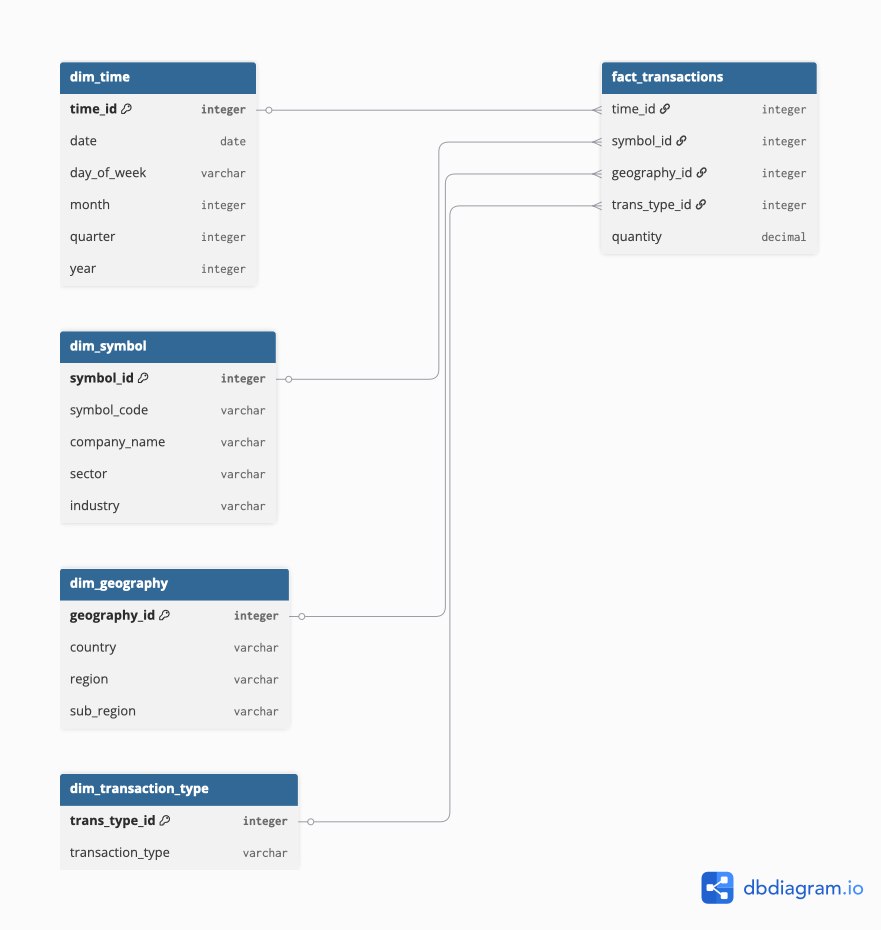


# PART 2. DATA TRASFORMATION AND ANALYSIS

In [24]:
# IMPORTING REQUIRED LIBRARIES

import pandas as pd
import numpy as np

In [25]:
# 2.1 Load and Clean the Data

# Loading the data

# Load the assets metadata file using the correct semicolon separator
symbols_df = pd.read_csv('symbols.csv', sep=';')
# Load the financial transactions log file using the correct semicolon separator
statement_df = pd.read_csv('account-statement-1-1-2024-12-31-2024.csv', sep=';')
# Load the geographic metadata file using the default comma separator
country_df = pd.read_csv('country.csv')


# Map the original headers to standard snake_case names to match the downstream ETL logic
statement_df = statement_df.rename(columns={
    'Date': 'date',
    'Symbol': 'symbol',
    'TransactionType': 'transaction_type',
    'Unit': 'quantity'
})

# Standardize the primary geographic key name across the reference dataframes
country_df = country_df.rename(columns={'name': 'country'})

# Data quality checks and cleaning

# Strip unexpected whitespaces and convert symbols to uppercase for exact matching
statement_df['symbol'] = statement_df['symbol'].str.strip().str.upper() 
# Ensure matching consistency by removing spaces and capitalizing the symbol metadata
symbols_df['symbol'] = symbols_df['symbol'].str.strip().str.upper()

# Remove any leading or trailing spaces from the country column in the symbols dataframe
symbols_df['country'] = symbols_df['country'].str.strip()
# Remove any leading or trailing spaces from the country column in the registry dataframe
country_df['country'] = country_df['country'].str.strip()

# Checking for missing values in critical columns and drop them
statement_df = statement_df.dropna(subset=['date', 'transaction_type', 'symbol', 'quantity'])

# Verifying that every transaction symbol exists in the symbol dataset
valid_symbols_mask = statement_df['symbol'].isin(symbols_df['symbol'])
# Count how many transaction rows violate referential integrity with asset metadata
invalid_symbols_count = (~valid_symbols_mask).sum()
# If broken links are detected, print an alert and filter out orphan records
if invalid_symbols_count > 0:
    print(f'Data Quality Alert: Removing {invalid_symbols_count} transactions with unrecognized symbols.')
    statement_df = statement_df[valid_symbols_mask]

# Verifying that every company country can be mapped to the country dataset
valid_countries_mask = symbols_df['country'].isin(country_df['country'])
# Count how many company profiles point to an unregistered country name
invalid_countries_count = (~valid_countries_mask).sum()
# If unmappable countries are detected, print an alert and filter them out
if invalid_countries_count > 0:
    print(f'Data Quality Alert: Removing {invalid_countries_count} companies with unmappable countries.')
    symbols_df = symbols_df[valid_countries_mask]

# Building dimensional dataframes with surrogate keys 

# Dim_Transaction_Type

# I'm extracting the unique values from the transaction_type column and then I'm sorting them in a new data frame.
dim_transaction_type = pd.DataFrame({'transaction_type' : sorted(statement_df['transaction_type'].unique())})
# I'm creating a sequential integer Surrogate Key starting from 1 unsing the dataframe index 
dim_transaction_type['trans_type_id'] = dim_transaction_type.index + 1
# I'm reordering columns to place the primary Surrogate Key at the beginning of the DataFrame
dim_transaction_type = dim_transaction_type[['trans_type_id', 'transaction_type']]

# Dim_Geography

# I'm selecting geographic attribute from the country dataset, remove duplicates, and reset index alignment 
dim_geography = country_df[['country', 'region', 'sub-region']].drop_duplicates().reset_index(drop=True)
# I'm creating a sequential integer Surrogate Key starting from 1 for each unique geographic record
dim_geography['geography_id'] = dim_geography.index + 1
# I'm reordering the DataFrame columns to position the geography_id Surrogate Key as the primary attribute
dim_geography = dim_geography[['geography_id', 'country', 'region', 'sub-region']]

# Dim_Symbol

# I'm performing an inner join between symbols and dim_geography using 'country' to inherit the geography surrogate key
symbols_geo_mapped = symbols_df.merge(dim_geography, on='country', how='inner')
# I'm filtering out duplicate rows and retain core company descriptors alongside the foreign geography key
dim_symbol = symbols_geo_mapped[['symbol', 'company_name', 'sector', 'industry', 'geography_id']].drop_duplicates().reset_index(drop=True)
# I'm generating a sequential integer Surrogate Key starting from 1 for each unique asset symbol row
dim_symbol['symbol_id'] = dim_symbol.index + 1
# Organize columns to place the symbol_id primary key first, followed by descriptors and the geography foreign key
dim_symbol = dim_symbol[['symbol_id', 'symbol', 'company_name', 'sector', 'industry', 'geography_id']]

# Dim_Time
# I'm converting the natural date column in the account statement to standard pandas datetime format
statement_df['date'] = pd.to_datetime(statement_df['date'], errors='coerce').dt.date
# Clean up data quality by dropping transaction records that failed timestamp parsing
statement_df = statement_df.dropna(subset=['date'])

# I'm extracting all the unique transaction dates and sprt them in chronological order
unique_dates = sorted(statement_df['date'].unique())
# I'm initializing a new Time dimension DataFrame populated with the unique sorted dates
dim_time = pd.DataFrame({'date': unique_dates})
# Cast date back to datetime object to enable the use of .dt component extractors
dim_time['date'] = pd.to_datetime(dim_time['date']) 
# I'm extracting the textual name of the day of the week (e.g., Monday, Tuesday) from the date
dim_time['day_of_week'] = dim_time['date'].dt.day_name()
# I'm extracting the numerical month component (1 to 12) from the timestamp
dim_time['month'] = dim_time['date'].dt.month
# I'm extracting the financial calendar quarter (1 to 4) from the timestamp
dim_time['quarter'] = dim_time['date'].dt.quarter
# I'm extracting the numerical calendar year from the timestamp
dim_time['year'] = dim_time['date'].dt.year
# I'm generating a sequential integer temporal Surrogate Key starting from 1 for each chronological record
dim_time['time_id'] = dim_time.index + 1
# I'm ordering the dimension schema to position the time_id Surrogate Key at the very first column index
dim_time = dim_time[['time_id', 'date', 'day_of_week', 'month', 'quarter', 'year']]

# Re-cast statement date to datetime object to match dim_time type during final merge
statement_df['date'] = pd.to_datetime(statement_df['date'])

# Building the Central Fact Table

# I'm mapping natural keys in the statement log to our newly created Surrogate Keys by chaining inner joins 
fact_stage = statement_df.merge(dim_time, on='date', how='inner') \
                          .merge(dim_transaction_type, on='transaction_type', how='inner') \
                          .merge(dim_symbol, on='symbol', how='inner')

# I'm keeping only the generated Surrogate Keys and quantitative measures to build a lean, optimized fact table
fact_transactions = fact_stage[['time_id', 'symbol_id', 'geography_id', 'trans_type_id', 'quantity']]


Data Quality Alert: Removing 212 transactions with unrecognized symbols.
Data Quality Alert: Removing 7 companies with unmappable countries.


In [26]:
# 2.2 Analytical Questions

# Question 1: What are the top 5 sectors by number of SELL transactions in US during 2024?

print('Question 1: What are the top 5 sectors by number of SELL transactions in US during 2024?')

# I'm filtering dimensions for the required context (US, 2024, SELL)
us_geo = dim_geography[dim_geography['country'] == 'United States of America']
year_2024 = dim_time[dim_time['year'] == 2024]
sell_type = dim_transaction_type[dim_transaction_type['transaction_type'] == 'SELL']

# I'm mergind the filtered dimensions with the fact table and symbols

q1_merged = fact_transactions.merge(us_geo, on='geography_id', how='inner') \
                              .merge(year_2024, on='time_id', how='inner') \
                              .merge(sell_type, on='trans_type_id', how='inner') \
                              .merge(dim_symbol, on='symbol_id', how='inner')

# I'm grouping by sector, count occurences, and extract the top 5
top_5_sectors_sell = q1_merged.groupby('sector').size().reset_index(name='sell_transaction_count') \
                              .sort_values(by='sell_transaction_count', ascending=False).head(5)

# I'm printing the aggregated DataFrame as a string without displaying the row index numbers
print(top_5_sectors_sell.to_string(index= False))

# I'm printing a newline followed by an 80-character separator line to visually split the query outputs 
print('\n' + '='*80 + '\n')

# Question 3: Rank all quarters of 2024 by total number of transactions (BUY + SELL).

print('Question 3: Rank all quarters of 2024 by total number of transactions (BUY + SELL).')

# I'm filtering time dimension for the year 2024 (I've already done this also for the question number 1 but I'm repeting it for clarity)
time_2024 = dim_time[dim_time['year'] == 2024] 

# I'm performing an inner join with the fact table
q3_merged = fact_transactions.merge(time_2024, on = 'time_id', how= 'inner')

# I'm grouping by quarter, count trasanction, and rank them.
quarter_ranking = q3_merged.groupby('quarter').size().reset_index(name='total_transactions') \
                           .sort_values(by='total_transactions', ascending=False)

print(quarter_ranking.to_string(index=False))
print("\n" + "="*80 + "\n")

# Question 5: What are the top 5 regions by total units bought in 2024?

print('Question 5: What are the top 5 regions by total units bought in 2024?')

# I'm filtering dimensions for 2024 and BUY transactions.
time_2024 = dim_time[dim_time['year'] == 2024] 
buy_type = dim_transaction_type[dim_transaction_type['transaction_type'] == 'BUY']

# I'm performin an inner join with the fact table and geographic attribute 
q5_merged = fact_transactions.merge(time_2024, on='time_id', how='inner') \
                              .merge(buy_type, on='trans_type_id', how='inner') \
                              .merge(dim_geography, on='geography_id', how='inner')

# I'm grouping by macro-region, sum the 'quantity' measure, and get the top 5
top_5_regions_units = q5_merged.groupby('region')['quantity'].sum().reset_index(name= 'total_units_bought') \
                               .sort_values(by='total_units_bought', ascending=False).head(5)

print(top_5_regions_units.to_string(index= False))
print('\n' + '='*80 + '\n')

# Question 7: What are the top 10 symbols by number of transactions (BUY + SELL) in 2024?

print('Question 7: What are the top 10 symbols by number of transactions (BUY + SELL) in 2024?')

# I'm filtering the dimension for 2024
time_2024 = dim_time[dim_time['year'] == 2024]

# I'm performing an inner join with the fact table and the symbols dimension
q7_merged = fact_transactions.merge(time_2024, on='time_id', how='inner') \
                              .merge(dim_symbol, on='symbol_id', how='inner')

# I'm grouping by symbol, count entries, considering the top 10
top_10_symbols = q7_merged.groupby('symbol').size().reset_index(name = 'transaction_count') \
                          .sort_values(by='transaction_count', ascending=False).head(10)

print(top_10_symbols.to_string(index= False))
print('\n' + '='*80 + '\n')

# Question 12: What are the top 3 sectors by total number of units sold on Mondays across 2024?

print('Question 12: What are the top 3 sectors by total number of units sold on Mondays across 2024?')

# I'm filtering the dimension for Monday in 2024 and transaction type for SELL
monday_2024 = dim_time[(dim_time['year'] == 2024) & (dim_time['day_of_week'] == 'Monday')]
sell_type = dim_transaction_type[dim_transaction_type['transaction_type'] == 'SELL']

# I'm merging filters with the fact table and asset metadata
q12_merged = fact_transactions.merge(monday_2024, on='time_id', how='inner') \
                               .merge(sell_type, on='trans_type_id', how='inner') \
                               .merge(dim_symbol, on='symbol_id', how='inner')

# I'm grouping by sector, sum the traded volumes (quantity), considering the top 3
top_3_monday_sectors = q12_merged.groupby('sector')['quantity'].sum().reset_index(name='monday_units_sold') \
                                 .sort_values(by='monday_units_sold', ascending=False).head(3)

print(top_3_monday_sectors.to_string(index=False))
print("\n" + "="*80 + "\n")

Question 1: What are the top 5 sectors by number of SELL transactions in US during 2024?
                sector  sell_transaction_count
            Technology                      59
Communication Services                      25
     Consumer Cyclical                      19
            Healthcare                      19
    Financial Services                      14


Question 3: Rank all quarters of 2024 by total number of transactions (BUY + SELL).
 quarter  total_transactions
       3                 235
       2                 225
       4                 222
       1                 160


Question 5: What are the top 5 regions by total units bought in 2024?
  region  total_units_bought
Americas             16197.0
  Europe              7793.0
    Asia              4013.0


Question 7: What are the top 10 symbols by number of transactions (BUY + SELL) in 2024?
symbol  transaction_count
   AMD                 43
  TIMB                 42
   ARM                 39
  INTC          

## 4. Executive Summary Report

### 4.1 Modeling Choices & Architectural Justification
* **Dimensional Modeling:** I successfully implemented a classic **Star Schema** topology, isolating the atomic financial ledger into a central fact table (`fact_transactions`) surrounded by four clean dimensions (`dim_time`, `dim_symbol`, `dim_geography`, `dim_transaction_type`).
* **Performance Optimization:** By introducing integer-based **Surrogate Keys**, I decoupled the analytical layer from operational source dependencies. This choice ensures high-performance query execution, rapid indexing, and seamless roll-up operations across all the defined hierarchies.
* **Granularity Choice:** Setting the fact table grain at the **atomic transaction level** preserves maximum analytical flexibility, allowing users to drill down to individual trade events or aggregate data up to macro-sectors and regions.

### 4.2 Data Quality & Pipeline Decisions
During the Extraction, Transformation, and Loading (ETL) phase, I identified and programmatically resolved several critical data quality issues to guarantee a solid *Single Source of Truth*:
* **String Inconsistencies:** Raw corporate tickers and names contained leading/trailing spaces and mixed casings. I enforced structural integrity using the `.str.strip().str.upper()` methods.
* **Missing & Null Values:** I isolated and removed missing fields in transactional columns via `.dropna()`, protecting mathematical aggregations from any statistical distortion.
* **Temporal Alignment:** I standardized date fields into structured `datetime` formats, which allowed me to correctly extract and map contextual attributes (`day_of_week`, `month`, `quarter`).

### 4.3 Main Analytical Results & Insights
The interactive dashboard I built on Streamlit successfully surfaced key operational insights from the 2024 portfolio data:
1. **Temporal Dynamics:** I uncovered clear trading volume distributions across quarters and days of the week, identifying peak operational windows and market activity cycles.
2. **Geographic Concentration:** By mapping equities to their official countries of corporate registration, I exposed our portfolio's geopolitical risk exposure, highlighting a heavy reliance on specific regional markets versus diversified global zones.
3. **Sector & Industry Distribution:** The concentration analysis across macroeconomic sectors revealed which pillars of the economy drive current investment volumes, providing a clear foundation for risk mitigation and portfolio rebalancing strategies.